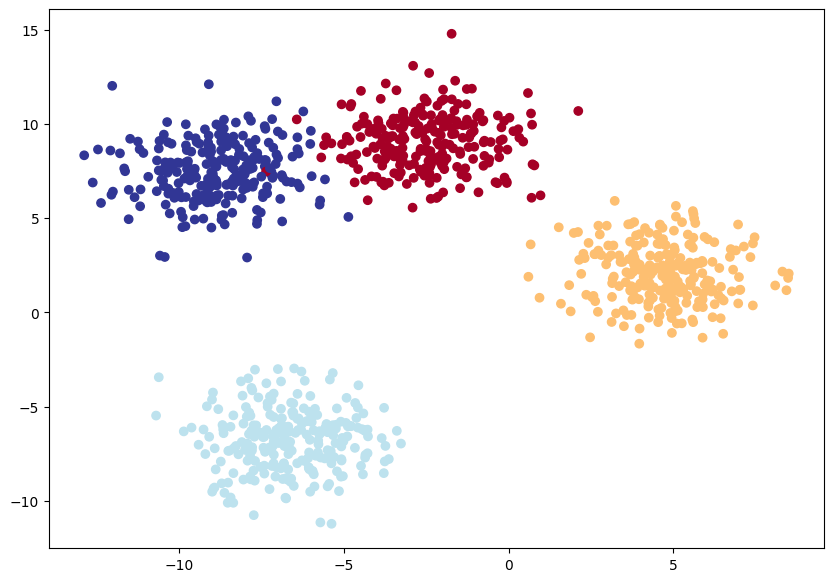

In [5]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from helper_functions import plot_decision_boundary

# Define hyperparameters
NUM_CLASSES = 4  # Number of output classes (features?)
NUM_FEATURES = 2  # Each coordinate is a feature
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(
    n_samples=1000,
    n_features=NUM_FEATURES,
    centers=NUM_CLASSES,
    cluster_std=1.5,
    random_state=RANDOM_SEED,
)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# 3. Split into train and test sets
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(
    X_blob, y_blob, test_size=0.2, random_state=RANDOM_SEED
)

# 4. Plot data
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)

In [6]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'mps'

In [7]:
from torch import nn


class BlobModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """Initialize all required hyperparameters for a multi-class classification model.

        Args:
            input_features (int): Number of input features to the model.
            out_features (int): Number of output features of the model (how many classes there are)
            hidden_units (int): Number of hidden units between layers, default 8.
        """
        super().__init__()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),  # Do we need non-linear layers?
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),  # Do we need non-linear layers?
            nn.Linear(in_features=hidden_units, out_features=output_features),
        )

    def forward(self, x):
        return self.linear_layer_stack(x)


model_4 = BlobModel(
    input_features=NUM_FEATURES, output_features=NUM_CLASSES, hidden_units=8
).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [8]:
loss_fn = nn.CrossEntropyLoss()

# So here we create an optimizer for the model_4. We are using Stochastic Gradient Descent
optimizer = torch.optim.SGD(model_4.parameters(), lr=0.1)  # Try to change learning rate

In [9]:
# We always need to remember to move data to our GPU
model_4(X_blob_train.to(device))[:5]

tensor([[ 0.3776, -0.1234,  0.1391, -0.5016],
        [ 2.2659, -0.1479, -0.2208,  1.8321],
        [ 0.3160, -0.0226, -0.0219, -0.0059],
        [ 0.3160, -0.0226, -0.0219, -0.0059],
        [ 1.8725, -0.1194, -0.1303,  1.5239]], device='mps:0',
       grad_fn=<SliceBackward0>)

In [10]:
model_4(X_blob_train.to(device))[0].shape, NUM_CLASSES

(torch.Size([4]), 4)

Logits are output of our model

In [11]:
# Make prediction logits with model
y_logits = model_4(X_blob_test.to(device))

# Perform softmax calculation on logits across dimension 1 to get prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
print(y_logits[:5])
print(y_pred_probs[:5])

tensor([[ 0.3222, -0.0329,  0.1217, -0.3875],
        [ 2.1654, -0.4263, -0.0423,  1.9283],
        [ 0.3160, -0.0226, -0.0219, -0.0059],
        [ 0.4984, -0.1675,  0.2163, -0.3177],
        [ 2.0269, -0.1261, -0.3204,  1.4755]], device='mps:0',
       grad_fn=<SliceBackward0>)
tensor([[0.3321, 0.2328, 0.2718, 0.1633],
        [0.5067, 0.0379, 0.0557, 0.3997],
        [0.3174, 0.2262, 0.2264, 0.2300],
        [0.3690, 0.1896, 0.2783, 0.1631],
        [0.5593, 0.0650, 0.0535, 0.3223]], device='mps:0',
       grad_fn=<SliceBackward0>)


In [12]:
torch.sum(y_pred_probs[0])

tensor(1., device='mps:0', grad_fn=<SumBackward0>)

In [13]:
print(y_pred_probs[0])
print(torch.argmax(y_pred_probs[0]))

tensor([0.3321, 0.2328, 0.2718, 0.1633], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor(0, device='mps:0')


In the beginning guessed probabilities are random, but training the model will give us the most probable classification.

Note: To summarize the above, a model's raw output is referred to as logits.

For a multi-class classification problem, to turn the logits into prediction probabilities, you use the softmax activation function (torch.softmax).

The index of the value with the highest prediction probability is the class number the model thinks is most likely given the input features for that sample (although this is a prediction, it doesn't mean it will be correct).

In [ ]:
def accuracy_fn(y_true, y_pred):
    correct = (
        torch.eq(y_true, y_pred).sum().item()
    )  # torch.eq() calculates where two tensors are equal and returns a tensor, so we need to use .item()
    acc = (correct / len(y_pred)) * 100

    return acc

In [15]:
torch.manual_seed(42)

epochs = 100

X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

for epoch in range(epochs):
    model_4.train()

    # 1. Forward pass
    y_logits = model_4(X_blob_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    # 2. Calculate loss and accuracy
    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train, y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    model_4.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_4(X_blob_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

        # 2. Calculate test loss and accuracy
        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_pred)

    if epoch % 10 == 0:
        print(
            f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%"
        )


Epoch: 0 | Loss: 1.17265, Acc: 25.12% | Test Loss: 1.04335, Test Acc: 52.50%
Epoch: 10 | Loss: 0.54396, Acc: 98.88% | Test Loss: 0.52331, Test Acc: 99.00%
Epoch: 20 | Loss: 0.34776, Acc: 99.12% | Test Loss: 0.34185, Test Acc: 99.50%
Epoch: 30 | Loss: 0.17953, Acc: 99.12% | Test Loss: 0.15960, Test Acc: 99.50%
Epoch: 40 | Loss: 0.07866, Acc: 99.12% | Test Loss: 0.06638, Test Acc: 99.50%
Epoch: 50 | Loss: 0.05528, Acc: 99.12% | Test Loss: 0.04493, Test Acc: 99.50%
Epoch: 60 | Loss: 0.04603, Acc: 99.12% | Test Loss: 0.03614, Test Acc: 99.50%
Epoch: 70 | Loss: 0.04089, Acc: 99.12% | Test Loss: 0.03117, Test Acc: 99.50%
Epoch: 80 | Loss: 0.03757, Acc: 99.12% | Test Loss: 0.02791, Test Acc: 99.50%
Epoch: 90 | Loss: 0.03524, Acc: 99.12% | Test Loss: 0.02560, Test Acc: 99.50%


In [16]:
model_4.eval()

with torch.inference_mode():
    y_logits = model_4(X_blob_test)

y_logits[:10]

tensor([[ 2.2228,  7.3677, -5.0789, -7.3358],
        [ 3.0520, -5.0175,  0.0362,  8.0905],
        [-1.3519, -0.9907,  5.6419, -1.6985],
        [ 0.1214,  4.9065, -2.2739, -4.5062],
        [ 7.6461,  2.5444, -7.0036, -3.0942],
        [ 3.3293, -5.9426,  0.1170,  9.7625],
        [-1.5470, -1.0482,  5.6510, -1.9380],
        [ 7.3379, -0.4242, -5.0225,  0.2195],
        [-1.3832, -1.1577,  6.3875, -0.9367],
        [ 7.3131,  0.6475, -5.6245, -0.9790]], device='mps:0')

In [17]:
y_pred_probs = torch.softmax(y_logits, dim=1)
y_preds = y_pred_probs.argmax(dim=1)

print(f"Predictions: {y_preds[:10]}\nLabels: {y_blob_test[:10]}")
print(f"Test accuracy: {accuracy_fn(y_true=y_blob_test, y_pred=y_preds)}")

Predictions: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='mps:0')
Labels: tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='mps:0')
Test accuracy: 99.5


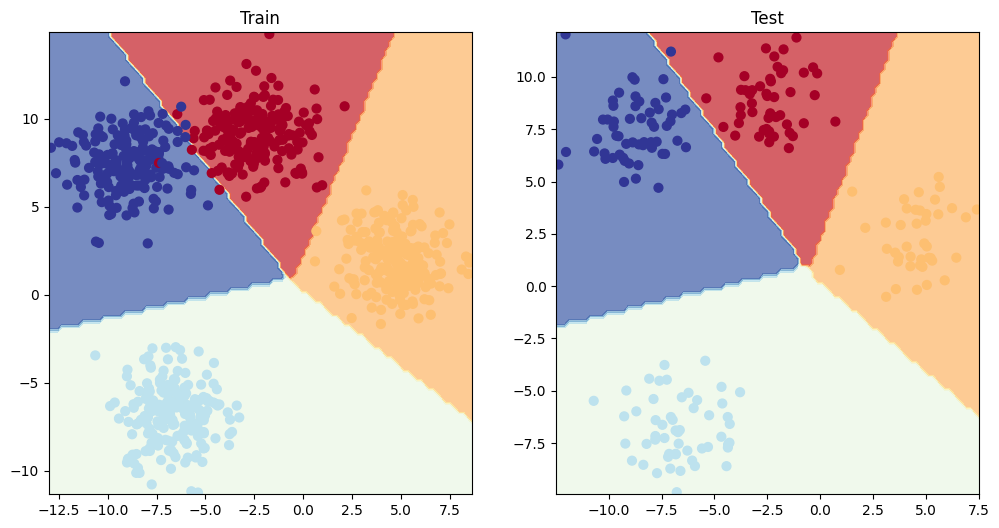

In [18]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

In [19]:
try:
    from torchmetrics import Accuracy
except:
    !pip install torchmetrics==0.9.3
    from torchmetrics import Accuracy

torchmetrics_accuracy = Accuracy(task="multiclass", num_classes=4).to(device)
torchmetrics_accuracy(y_preds, y_blob_test)

/Users/sebastianflajszer/Projects/lp/.venv/lib/python3.12/site-packages/torchmetrics/utilities/imports.py:23: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


tensor(0.9950, device='mps:0')